In [1]:
import os
os.chdir('./../')

In [10]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [3]:
def entropy(probs):
    probs = np.array(probs)
    return -np.sum(probs * np.log(probs + 1e-12))  # epsilon avoids log(0)

In [4]:
tang_csv = pd.read_csv("csv/tang_et_al_2019_sngp_pca_features.csv")

In [5]:
tang_csv["class_probs"] = tang_csv["class_probs"].apply(ast.literal_eval)
tang_csv["entropy"] = tang_csv["class_probs"].apply(entropy)

ValueError: cannot reshape array of size 352 into shape (352,352)

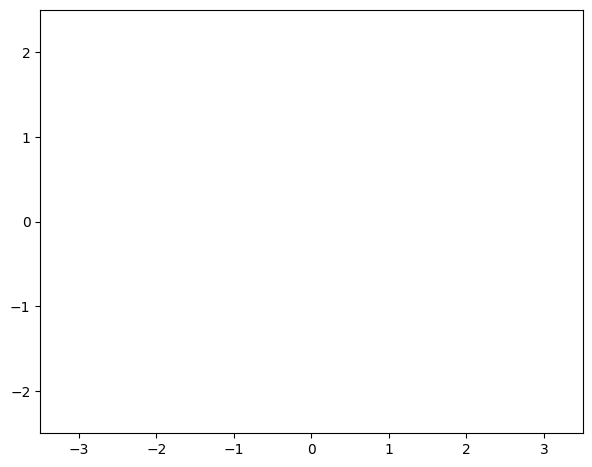

In [11]:
_, ax = plt.subplots(figsize=(7, 5.5))
test_uncertainty = tang_csv['entropy'].values
test_uncertainty = test_uncertainty / np.max(test_uncertainty)

DEFAULT_X_RANGE = (-3.5, 3.5)
DEFAULT_Y_RANGE = (-2.5, 2.5)

DEFAULT_N_GRID = len(test_uncertainty)

# # Set view limits.
ax.set_ylim(DEFAULT_Y_RANGE)
ax.set_xlim(DEFAULT_X_RANGE)

DEFAULT_NORM = colors.Normalize(
    vmin=0,
    vmax=1,
)
# Plot normalized uncertainty surface.
pcm = ax.imshow(
    np.reshape(test_uncertainty, [DEFAULT_N_GRID, DEFAULT_N_GRID]),
    cmap=None,
    origin="lower",
    extent=DEFAULT_X_RANGE + DEFAULT_Y_RANGE,
    vmin=DEFAULT_NORM.vmin,
    vmax=DEFAULT_NORM.vmax,
    interpolation="bicubic",
    aspect="auto",
)